---
## Setup

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.applications.convnext import ConvNeXtTiny, preprocess_input
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [25]:
# Image Credits: Tensorflow Doc
content_path = tf.keras.utils.get_file(
  'content.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')

style_path = tf.keras.utils.get_file(
  'style.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

---
## Preprocess

In [26]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def load_and_process_image(path_to_img, max_dim=512):
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0, 1]

    shape = tf.shape(img)[:-1]
    long_dim = tf.reduce_max(tf.cast(shape, tf.float32))
    scale = max_dim / long_dim
    new_shape = tf.cast(tf.cast(shape, tf.float32) * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = tf.expand_dims(img, axis=0)  # Tambahkan batch dimension

    img = preprocess_input(img * 255.0)  # Skala ke [0, 255] lalu preprocessing
    return img


In [27]:
def deprocess(img):
    if isinstance(img, tf.Tensor):
        img = img.numpy()
    img = img.copy()

    if len(img.shape) == 4:
        img = img[0]  # remove batch dimension

    # Tambahkan kembali mean dan ubah ke RGB
    img[:, :, 0] += 103.939  # B
    img[:, :, 1] += 116.779  # G
    img[:, :, 2] += 123.68   # R

    img = img[:, :, ::-1]  # BGR to RGB
    img = np.clip(img, 0, 255).astype('uint8')
    return img


def display_image(img):
    img = deprocess(img)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


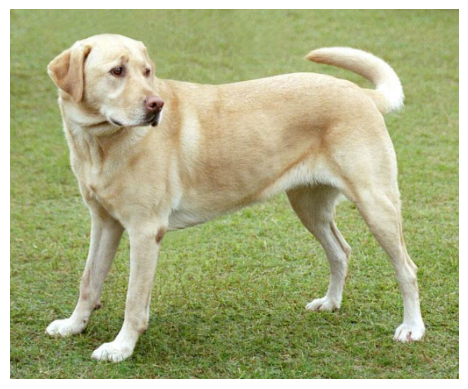

In [28]:
content_img = load_and_process_image(content_path)
display_image(content_img)

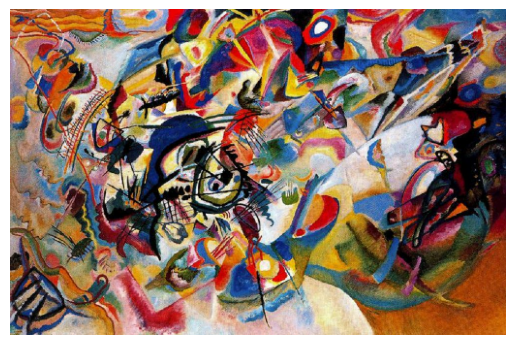

In [29]:
style_img = load_and_process_image(style_path)
display_image(style_img)

---
## Model Initialization

In [30]:
model_VGG19 = VGG19(
    include_top=False,
    weights='imagenet'
)
content_layer = 'block5_conv2'
content_model = Model(inputs = model_VGG19.input,
                      outputs = model_VGG19.get_layer(content_layer).output)

content_model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 15,304,768 (58.38 MB)

 Trainable params: 15,304,768 (58.38 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model_EfficientNetB0 = EfficientNetB0(
    include_top = False,
    weights = 'imagenet'
)
model_EfficientNetB0.trainable = False
model_EfficientNetB0.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [32]:
model_ConvNeXtTiny = ConvNeXtTiny(include_top=False,
                          weights="imagenet")


model_ConvNeXtTiny.trainable = False
model_ConvNeXtTiny.summary()

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "convnext_tiny"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, None,      │          0 │ input_layer_2[0]… │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, None,      │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ convnext_tiny_st… │
│                     │ None, 96)         │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ add[0][0]         │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st

 Total params: 27,820,128 (106.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27,820,128 (106.13 MB)

In [33]:
content_layer = 'block5_conv2'
content_model = Model(inputs = model_VGG19.input,
                      outputs = model_VGG19.get_layer(content_layer).output)

style_layers = [
    'stem_activation',
    'block2a_activation',
    'block3a_activation',
    'block4a_activation',
    'block5a_activation'
]

style_models = [Model(inputs=model_EfficientNetB0.input,
                      outputs=model_EfficientNetB0.get_layer(layer).output)for layer in style_layers]

---
#### Content Loss

In [34]:
def content_loss(content, generated):
    a_C = content_model(content)
    a_G = content_model(generated)
    loss = tf.reduce_mean(tf.square(a_C - a_G))
    return loss

---
#### gram matrix

In [35]:
def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a,a,transpose_a = True)
    return gram/tf.cast(n, tf.float32)

weight_of_layer =  1./len(style_layers)

---
#### Style Loss

In [36]:
def style_cost(style, generated):
    J_style = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_generated - gram_a_style ))
        J_style += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_style

---
#### content cost

In [37]:
def content_cost(style, generated):
    J_content = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_style - gram_a_generated))
        J_content += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_content

---
#### Training Functions

In [38]:
import os
import tensorflow as tf
import numpy as np
import time
import math

generated_images = []

def save_checkpoint(generated, iteration, path="checkpoint.npz"):
    np.savez(path, generated=generated.numpy(), iteration=iteration)

def load_checkpoint(path="checkpoint.npz"):
    data = np.load(path)
    return tf.Variable(data["generated"], dtype=tf.float32), int(data["iteration"])

def training_loop(content_path, style_path, iterations, start_iter=0, a=10, b=1000, checkpoint_path="checkpoint.npz"):
    content = load_and_process_image(content_path)
    style = load_and_process_image(style_path)

    # Load previous checkpoint if available
    if start_iter > 0 and os.path.exists(checkpoint_path):
        generated, start_iter = load_checkpoint(checkpoint_path)
        print(f"Resuming from iteration {start_iter}")
    else:
        generated = tf.Variable(content, dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=0.7)
    best_cost = math.inf
    best_image = None

    for i in range(start_iter + 1, start_iter + iterations + 1):
        start_time_cpu = time.process_time()
        start_time_wall = time.time()

        with tf.GradientTape() as tape:
            J_content = content_cost(content, generated)
            J_style = style_cost(style, generated)
            J_total = a * J_content + b * J_style

        grads = tape.gradient(J_total, generated)
        opt.apply_gradients([(grads, generated)])

        end_time_cpu = time.process_time()
        end_time_wall = time.time()
        cpu_time = end_time_cpu - start_time_cpu
        wall_time = end_time_wall - start_time_wall

        if J_total < best_cost:
            best_cost = J_total
            best_image = generated.numpy()

        print(f"Iteration: {i}")
        print(f"CPU Time: {cpu_time * 1e6:.2f} µs, Wall Time: {wall_time * 1e6:.2f} µs")
        print(f"Total Loss: {J_total:.4e}")

        if i % 100 == 0:
            print(f"Saving checkpoint at iteration {i}")
            generated_images.append(generated.numpy())
            save_checkpoint(generated, i, path=checkpoint_path)

    return best_image

In [39]:
final_image = training_loop(content_path, style_path, iterations=1500)

Iteration: 1
CPU Time: 4391795.68 µs, Wall Time: 5368119.00 µs
Total Loss: 2.7880e+06
Iteration: 2
CPU Time: 2733739.90 µs, Wall Time: 2733170.03 µs
Total Loss: 2.7376e+06
Iteration: 3
CPU Time: 3218602.75 µs, Wall Time: 3267681.84 µs
Total Loss: 2.6877e+06
Iteration: 4
CPU Time: 2653157.56 µs, Wall Time: 2647284.03 µs
Total Loss: 2.6386e+06
Iteration: 5
CPU Time: 2682412.41 µs, Wall Time: 2672867.30 µs
Total Loss: 2.5902e+06
Iteration: 6
CPU Time: 2647343.68 µs, Wall Time: 2639843.46 µs
Total Loss: 2.5426e+06
Iteration: 7
CPU Time: 3288567.64 µs, Wall Time: 3339537.38 µs
Total Loss: 2.4958e+06
Iteration: 8
CPU Time: 2649886.87 µs, Wall Time: 2644093.51 µs
Total Loss: 2.4498e+06
Iteration: 9
CPU Time: 2691645.35 µs, Wall Time: 2692095.04 µs
Total Loss: 2.4045e+06
Iteration: 10
CPU Time: 2659590.07 µs, Wall Time: 2655958.18 µs
Total Loss: 2.3599e+06
Iteration: 11
CPU Time: 3535602.14 µs, Wall Time: 3585916.28 µs
Total Loss: 2.3159e+06
Iteration: 12
CPU Time: 2677427.30 µs, Wall Time: 26

---
#### Results

In [40]:
# Deprocess dulu biar bisa ditampilin
def deprocess(img):
    img = img.copy()  # supaya gak error read-only
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR ke RGB
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def display_image(img_array):
    if len(img_array.shape) == 4:
        img_array = np.squeeze(img_array, axis=0)
    img = deprocess(img_array)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

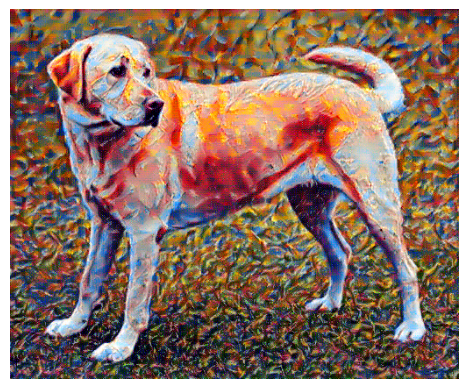

In [41]:
last_generated = generated_images[-1]

# Ayo kita lihat hasil terakhir
display_image(last_generated)